In [4]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

base_path = r"D:\cnn proj\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)"
train_path = os.path.join(base_path, "train")
valid_path = os.path.join(base_path, "valid")

print("Train folders:", len(os.listdir(train_path)))

C:\Users\R Ranjith Kumar\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Train folders: 38


## 2. Data Loading & Augmentation

In [5]:
# Image size 224x224 is best for MobileNetV2
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(rescale=1./255)

train_set = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_set = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


## 3. Build the CNN Model (Transfer Learning)

In [6]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.2), 
    layers.Dense(38, activation='softmax') 
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,933,350 (11.19 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
history = model.fit(
    train_set,
    validation_data=valid_set,
    epochs=5,
    steps_per_epoch=100, 
    validation_steps=50   
)

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 88s 816ms/step - accuracy: 0.5800 - loss: 1.5613 - val_accuracy: 0.7887 - val_loss: 0.7507
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 78s 781ms/step - accuracy: 0.7822 - loss: 0.6935 - val_accuracy: 0.7987 - val_loss: 0.5969
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 756ms/step - accuracy: 0.8238 - loss: 0.5509 - val_accuracy: 0.8587 - val_loss: 0.4488
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 75s 749ms/step - accuracy: 0.8531 - loss: 0.4681 - val_accuracy: 0.8512 - val_loss: 0.4580
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 76s 761ms/step - accuracy: 0.8747 - loss: 0.4184 - val_accuracy: 0.8550 - val_loss: 0.4177


In [8]:
import cv2
import numpy as np 

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


labels = dict((v, k) for k, v in train_set.class_indices.items())

def predict_and_show(image_path):
    
    img = cv2.imread(image_path)

    if img is None:
        print(" Error: Image not found. Check path.")
        return

    # Preprocess
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)

    # Prediction
    prediction = model.predict(img_input)
    predicted_class_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100


    raw_label = labels[predicted_class_index]

    
    clean_name = raw_label.replace("_", " ").replace("___", " - ")

    
    if "healthy" in raw_label.lower():
        status = "HEALTHY"
        display_color = "green"
    else:
        status = "DISEASED"
        display_color = "red"

    
    plt.figure(figsize=(6, 6))
    plt.imshow(img_resized)
    plt.title(
        f"[{status}]\n{clean_name}\nConfidence: {confidence:.2f}%",
        color=display_color,
        fontsize=14,
        fontweight='bold'
    )
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step


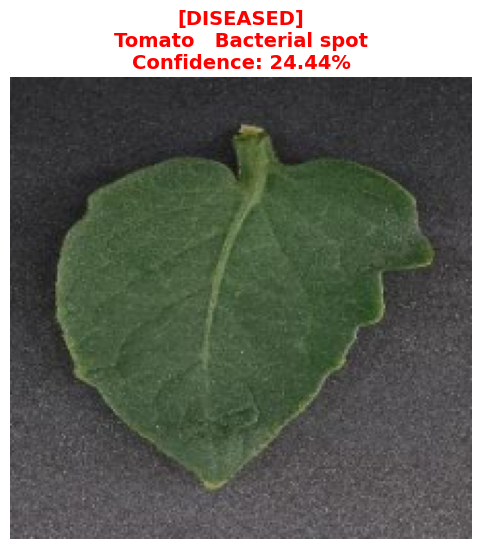

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


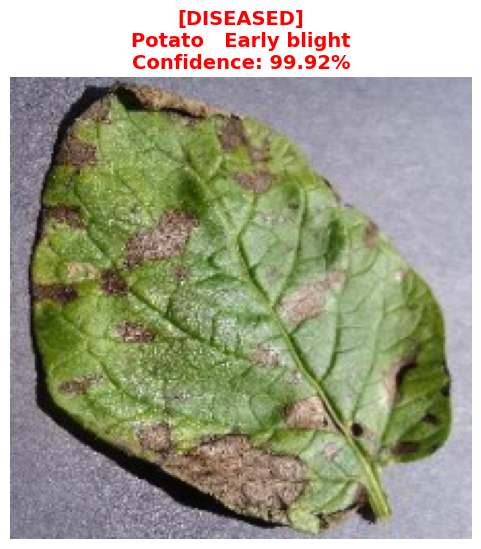

In [11]:
predict_and_show(r"D:\cnn proj\test\test\TomatoHealthy2.JPG")
predict_and_show(r"D:\cnn proj\test\test\PotatoEarlyBlight1.JPG")